# Project - 2 IPL / Sports data analysis
1. Analyze match / player CSVs to get top scorers, strike rates, team win rates.
2. Visualize per-season and per-player metrics.
3. Compare player performance across seasons.
4. Export visual summary and short insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(7)
plt.rcParams["figure.dpi"] = 110

In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")
deliveries = deliveries.merge(matches[["id", "season"]], left_on="match_id", right_on="id", how="left")
balls_faced_mask = deliveries["extras_type"] != "wides"

### KPIs - Top scorers, strike rates, Team win rates

In [3]:
runs_per_player = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)
runs_per_player 

batter
V Kohli         8014
S Dhawan        6769
RG Sharma       6630
DA Warner       6567
SK Raina        5536
                ... 
S Ladda            0
S Lamichhane       0
Abdur Razzak       0
SS Cottrell        0
KM Asif            0
Name: batsman_runs, Length: 673, dtype: int64

In [ ]:
balls_per_player = deliveries[balls_faced_mask].groupby("batter")["batsman_runs"].count()
strike_rate = (runs_per_player / balls_per_player * 100).round(1)
top_scorers = runs_per_player.head(5)
top_strike_rates = strike_rate[balls_per_player >= 500].sort_values(ascending=False).head(5)
decided = matches.dropna(subset=["winner"])
games_played = pd.concat([decided["team1"], decided["team2"]]).value_counts()
wins = decided["winner"].value_counts()
win_rate = (wins / games_played * 100).round(1).sort_values(ascending=False)
win_rate = win_rate[games_played >= 20]
best_player = top_scorers.index[0]
player_season_runs = deliveries[deliveries["batter"] == best_player].groupby("season")["batsman_runs"].sum()

In [5]:
print("Top 5 Run Scorers (career)")
print(top_scorers.to_string())

Top 5 Run Scorers (career)
batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536


In [6]:
print("Top 5 Strike Rates (min 500 balls faced)")
print(top_strike_rates.to_string())

Top 5 Strike Rates (min 500 balls faced)
batter
AD Russell        174.8
H Klaasen         168.3
SP Narine         165.8
LS Livingstone    162.5
N Pooran          162.0


In [7]:
print("Team Win Rates, % (min 20 matches played)")
print(win_rate.to_string())

Team Win Rates, % (min 20 matches played)
Gujarat Titans                 62.2
Chennai Super Kings            58.2
Lucknow Super Giants           55.8
Mumbai Indians                 55.2
Delhi Capitals                 52.7
Kolkata Knight Riders          52.2
Rajasthan Royals               51.1
Royal Challengers Bangalore    48.9
Sunrisers Hyderabad            48.4
Kings XI Punjab                46.3
Gujarat Lions                  43.3
Punjab Kings                   42.9
Delhi Daredevils               42.1
Deccan Chargers                38.7
Pune Warriors                  26.7


### Visualization

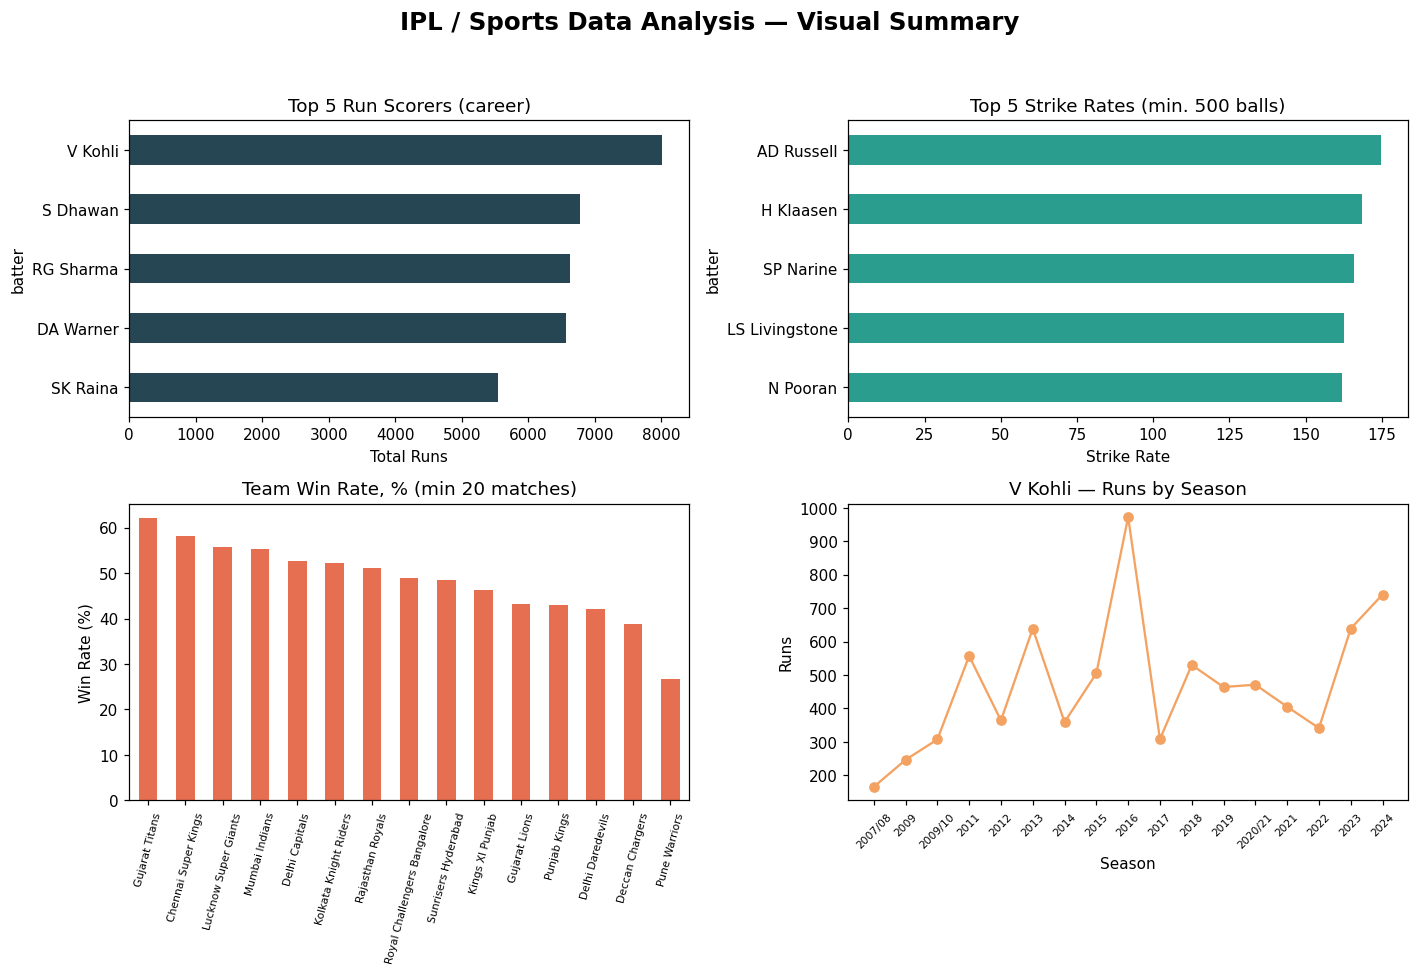

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("IPL / Sports Data Analysis — Visual Summary", fontsize=16, fontweight="bold")

ax = axes[0, 0]
top_scorers.sort_values().plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Top 5 Run Scorers (career)")
ax.set_xlabel("Total Runs")

ax = axes[0, 1]
top_strike_rates.sort_values().plot(kind="barh", ax=ax, color="#2A9D8F")
ax.set_title("Top 5 Strike Rates (min. 500 balls)")
ax.set_xlabel("Strike Rate")

ax = axes[1, 0]
win_rate.plot(kind="bar", ax=ax, color="#E76F51")
ax.set_title("Team Win Rate, % (min 20 matches)")
ax.set_ylabel("Win Rate (%)")
ax.tick_params(axis="x", rotation=75, labelsize=7)

ax = axes[1, 1]
ax.plot(player_season_runs.index.astype(str), player_season_runs.values, marker="o", color="#F4A261")
ax.set_title(f"{best_player} — Runs by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Runs")
ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ipl_summary.png", bbox_inches="tight")

### Insights

In [9]:
print("Insights")
print(f"1. {top_scorers.index[0]} is the top run-scorer across all seasons with "
      f"{top_scorers.iloc[0]:,} runs.")
print(f"2. {top_strike_rates.index[0]} has the best strike rate among high-volume batters "
      f"({top_strike_rates.iloc[0]}), well ahead of most contemporaries.")
print(f"3. {win_rate.index[0]} has the highest win rate at {win_rate.iloc[0]}%, "
      f"while {win_rate.index[-1]} trails at {win_rate.iloc[-1]}% among teams with a "
      f"meaningful number of matches played.")

Insights
1. V Kohli is the top run-scorer across all seasons with 8,014 runs.
2. AD Russell has the best strike rate among high-volume batters (174.8), well ahead of most contemporaries.
3. Gujarat Titans has the highest win rate at 62.2%, while Pune Warriors trails at 26.7% among teams with a meaningful number of matches played.
